### Метод градиентного спуска

Пусть требуется решить задачу: $f(x, y) \to min$


In [3]:
import numpy as np
def f(x, y):
    return 8*np.sin(2*np.pi*x)*np.cos(0.5*np.pi*y)*(1-x**2)*y*(1-y)

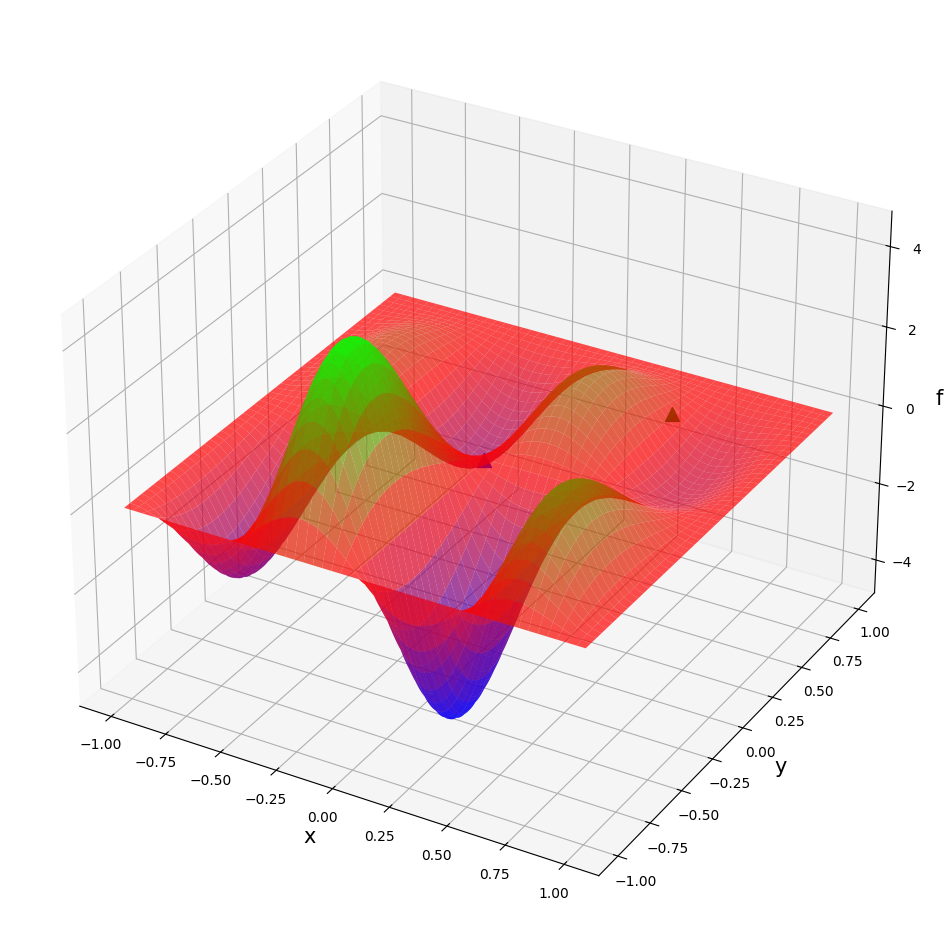

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (12, 12))

# последовательностьточек по осям
x = np.linspace(-1, 1, 1000)
y = np.linspace(-1, 1, 1000)

# координатная плоскость
X, Y = np.meshgrid(x, y)

F = f(X, Y)
L = np.zeros(X.shape)

ax = fig.add_subplot(projection = '3d')
ax.plot_surface(X, Y, F, alpha = 0.7, cmap = 'brg')
#ax.plot_surface(X, Y, L, alpha = 1.0)

ax.scatter(0.6, 0.4, 1, c = 'green', marker = '^', s = 100)
ax.scatter(0, 0, 0, c = 'blue', marker = '^', s = 100)

# подписи к осям
ax.set_xlabel('x', fontsize = 15)
ax.set_ylabel('y', fontsize = 15)
ax.set_zlabel('f', fontsize = 15)

# выведем результат
plt.show()

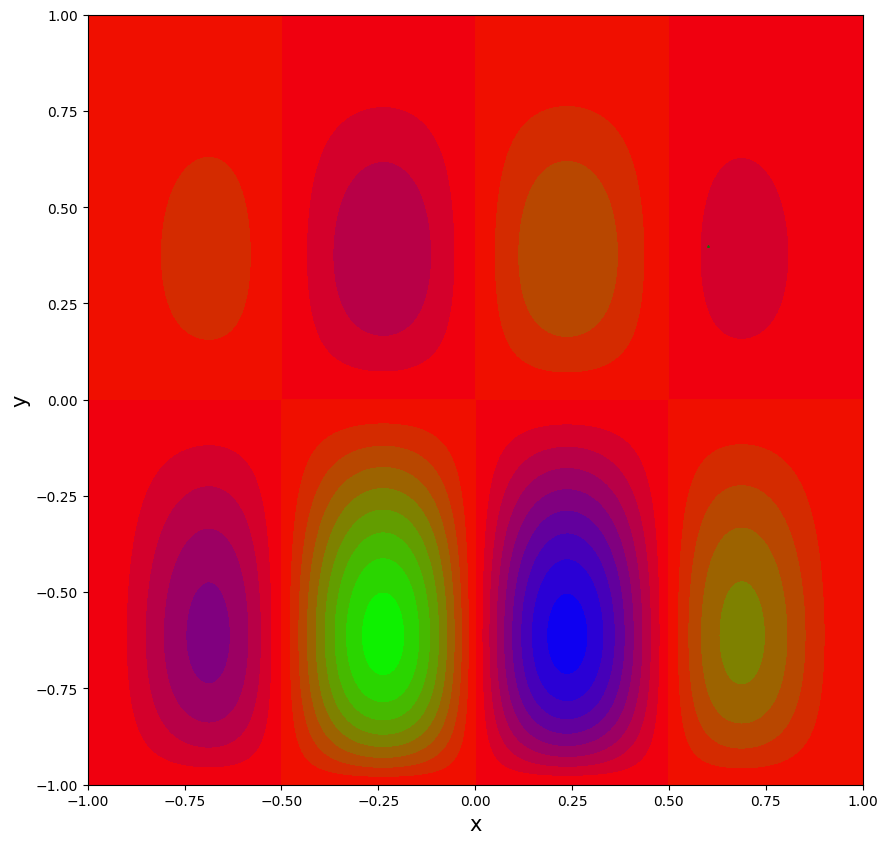

In [5]:
fig, ax = plt.subplots(figsize = (10,10))

# изолинии
ax.contourf(X, Y, F, cmap = 'brg', levels = 20)

ax.scatter(0.6, 0.4, 1, c = 'green', marker = '^')
ax.scatter(0, 0, 0, c = 'blue', marker = '^')

# подписи к осям
ax.set_xlabel('x', fontsize = 15)
ax.set_ylabel('y', fontsize = 15)

#plt.grid(linestyle = '--')

# выведем результат
plt.show()

In [6]:
!pip install sympy

In [7]:
import sympy as sym
from sympy.abc import x, y

In [8]:
f_sym = 8*sym.sin(2*sym.pi*x)*sym.cos(0.5*sym.pi*y)*(1-x**2)*y*(1-y)

In [9]:
df_dx_sym = sym.diff(f_sym, x)
df_dy_sym = sym.diff(f_sym, y)
df_dx_num = sym.lambdify((x, y), df_dx_sym, 'numpy')
df_dy_num = sym.lambdify((x, y), df_dy_sym, 'numpy')

In [10]:
df_dx_sym

-16*x*y*(1 - y)*sin(2*pi*x)*cos(pi*y/2) + 16*pi*y*(1 - x**2)*(1 - y)*cos(2*pi*x)*cos(pi*y/2)

In [11]:
df_dy_sym

-4*pi*y*(1 - x**2)*(1 - y)*sin(2*pi*x)*sin(pi*y/2) - 8*y*(1 - x**2)*sin(2*pi*x)*cos(pi*y/2) + 8*(1 - x**2)*(1 - y)*sin(2*pi*x)*cos(pi*y/2)

### Реализация градиентного спуска

In [12]:
def gradient_descent(x0, y0, lr=0.01, n_iter=200, tol=1e-6):
    path = [(x0, y0)]
    xs, ys = x0, y0
    for _ in range(n_iter):
        gx, gy = df_dx_num(xs, ys), df_dy_num(xs, ys)
        xs_new = xs - lr * gx
        ys_new = ys - lr * gy
        path.append((xs_new, ys_new))
        if np.hypot(xs_new - xs, ys_new - ys) < tol:
            break
        xs, ys = xs_new, ys_new
    return np.array(path)

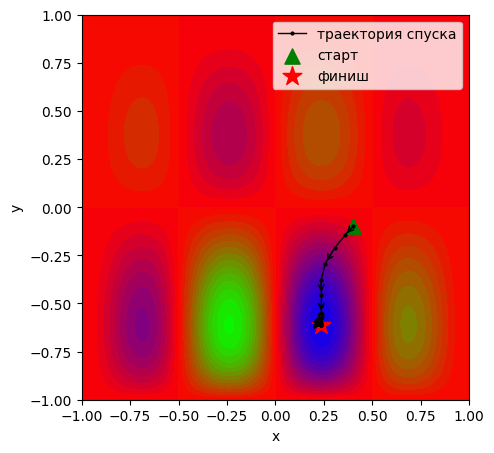

In [15]:
path = gradient_descent(0.4, -0.1, lr=0.01, n_iter=200)

fig, ax = plt.subplots(figsize=(5,5))
ax.contourf(X, Y, F, cmap='brg', levels=30)
ax.plot(path[:,0], path[:,1], 'k.-', lw=1, ms=4, label='траектория спуска')
ax.scatter(path[0,0], path[0,1], c='green', marker='^', s=120, label='старт')
ax.scatter(path[-1,0], path[-1,1], c='red', marker='*', s=200, label='финиш')
# стрелки направления движения
for i in range(0, len(path)-1, max(1, len(path)//15)):
    ax.annotate('', xy=path[i+1], xytext=path[i],
                arrowprops=dict(arrowstyle='->', color='k', lw=1))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

### Векторное поле градиента

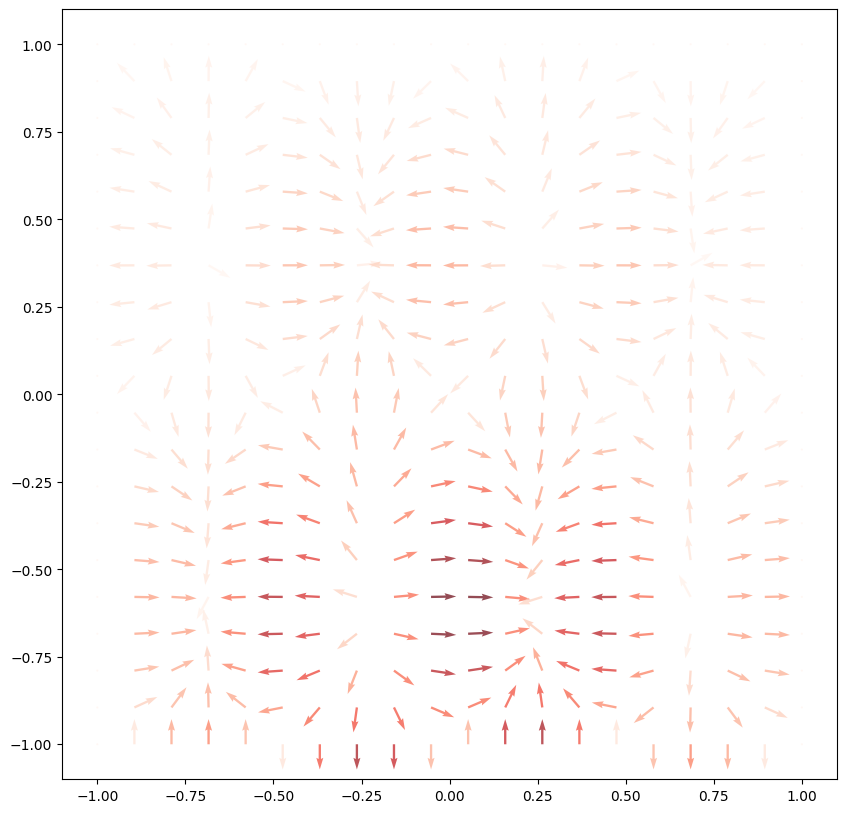

In [14]:
fig, ax = plt.subplots(figsize=(10,10))
xg = np.linspace(-1, 1, 20)
yg = np.linspace(-1, 1, 20)
Xg, Yg = np.meshgrid(xg, yg)
U, V = df_dx_num(Xg, Yg), df_dy_num(Xg, Yg)
N = np.hypot(U, V) + 1e-12
ax.quiver(Xg, Yg, -U/N, -V/N, N, cmap='Reds', alpha=0.7)
plt.show()

In [ ]:
np.linalg.solve(A, b)